In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

from mimiciii_db import DB
from mimiciii_db.config import db_url



In [50]:
# Connect to database
db = DB.from_url(db_url())
print("Database connected successfully!")


Database connected successfully!


In [51]:
# Load patients data
print("Loading patients data...")
patients = db.table_df("patients", schema="mimiciii")
print(f"Loaded{len(patients)} patients")
print(f"Shape: {patients.shape}")
print(f"Columns: {list(patients.columns)}")



Loading patients data...
Loaded46520 patients
Shape: (46520, 8)
Columns: ['row_id', 'subject_id', 'gender', 'dob', 'dod', 'dod_hosp', 'dod_ssn', 'expire_flag']


In [52]:
# First look at the data
print("First 5 rows:")
display(patients.head())

print("\n Data types:")
print(patients.dtypes)

print("\n Basic statistics:")
display(patients.describe(include='all'))


First 5 rows:


,row_id,subject_id,gender,dob,dod,dod_hosp,dod_ssn,expire_flag
0,234,249,F,2075-03-13,NaT,NaT,NaT,0
1,235,250,F,2164-12-27,2188-11-22,2188-11-22,NaT,1
2,236,251,M,2090-03-15,NaT,NaT,NaT,0
3,237,252,M,2078-03-06,NaT,NaT,NaT,0
4,238,253,F,2089-11-26,NaT,NaT,NaT,0



 Data types:
row_id                  int64
subject_id              int64
gender                 object
dob            datetime64[ns]
dod            datetime64[ns]
dod_hosp       datetime64[ns]
dod_ssn        datetime64[ns]
expire_flag             int64
dtype: object

 Basic statistics:


,row_id,subject_id,gender,dob,dod,dod_hosp,dod_ssn,expire_flag
count,46520.000000,46520.000000,46520,46520,15759,9974,13378,46520.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,M,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,26121,NaN,NaN,NaN,NaN,NaN
mean,23260.500000,34425.772872,NaN,2088-12-15 00:15:58.349096960,2152-07-21 07:29:01.404910592,2151-11-22 01:33:07.327049728,2152-09-01 23:24:15.822993408,0.338758
min,1.000000,2.000000,NaN,1800-07-02 00:00:00,2100-06-19 00:00:00,2100-06-19 00:00:00,2100-06-19 00:00:00,0.000000
25%,11630.750000,12286.750000,NaN,2063-08-30 18:00:00,2127-04-02 12:00:00,2126-10-19 00:00:00,2127-04-11 18:00:00,0.000000
50%,23260.500000,24650.500000,NaN,2096-07-11 00:00:00,2152-07-06 00:00:00,2151-05-15 00:00:00,2152-08-23 00:00:00,0.000000
75%,34890.250000,55477.500000,NaN,2124-11-29 06:00:00,2177-12-28 00:00:00,2177-06-12 12:00:00,2178-02-10 00:00:00,1.000000
max,46520.000000,99999.000000,NaN,2201-07-24 00:00:00,2211-06-10 00:00:00,2209-01-08 00:00:00,2211-06-10 00:00:00,1.000000


Gender Distribution:
gender
M    26121
F    20399
Name: count, dtype: int64


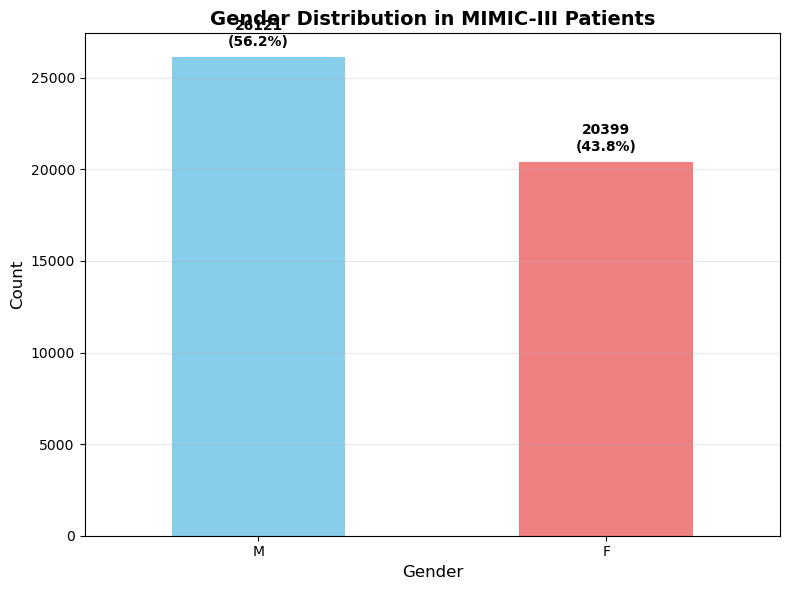

In [53]:
# Gender Distribution
print("Gender Distribution:")
gender_counts = patients['gender'].value_counts()
print(gender_counts)

# Visualize gender distribution
plt.figure(figsize=(8, 6))
gender_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Gender Distribution in MIMIC-III Patients', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add percentage labels
total = len(patients)
for i, v in enumerate(gender_counts.values):
    plt.text(i, v + total*0.01, f'{v}\n({v/total*100:.1f}%)', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


Age stats (adults 18–89):
count      48149.0
mean     62.054788
std      16.476444
min           18.0
50%           64.0
90%           82.0
95%           85.0
max           89.0


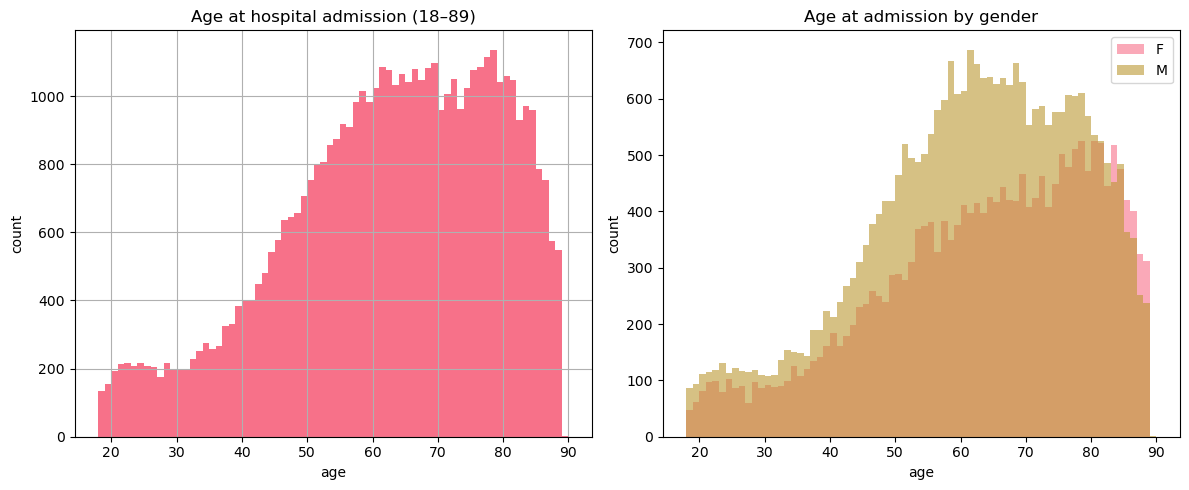

In [61]:
# Age at admission computed like: EXTRACT(YEAR FROM AGE(admittime, dob))

import pandas as pd
import matplotlib.pyplot as plt

# 1) pull DOB, gender, and admission time
patients = db.query_df("SELECT subject_id, dob, gender FROM mimiciii.patients")
admissions = db.query_df("""
    SELECT subject_id, hadm_id, admittime
    FROM mimiciii.admissions
    WHERE admittime IS NOT NULL
""")

# 2) join and parse datetimes
df = admissions.merge(patients, on="subject_id", how="left").copy()
df["dob"] = pd.to_datetime(df["dob"], errors="coerce")
df["admittime"] = pd.to_datetime(df["admittime"], errors="coerce")

# 3) exact integer years at admission (Postgres AGE years component)
#    years = adm.year - dob.year - 1{if birthday hasn't occurred yet}
year_diff = df["admittime"].dt.year - df["dob"].dt.year
bday_not_reached = (
    (df["admittime"].dt.month*100 + df["admittime"].dt.day)
    < (df["dob"].dt.month*100 + df["dob"].dt.day)
).astype(int)
df["age"] = (year_diff - bday_not_reached).astype("Int64")

# 4) handle edge cases in MIMIC-III de-identification:
#    very old patients have shifted DOB -> huge ages; standard practice is set to 90.
df["age"] = df["age"].where(df["age"] < 200, 90)
df = df[df["age"].notna()].copy()

# (optional) keep adults and exclude 90+ if you want to match many EDA plots
adults = df[(df["age"] >= 18) & (df["age"] < 90)].copy()

print("Age stats (adults 18–89):")
print(adults["age"].describe(percentiles=[.5,.9,.95]).to_string())

# 5) quick plots
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
adults["age"].hist(bins=range(18,91))
plt.title("Age at hospital admission (18–89)")
plt.xlabel("age"); plt.ylabel("count")

plt.subplot(1,2,2)
for g, sub in adults.groupby("gender"):
    plt.hist(sub["age"], bins=range(18,91), alpha=0.6, label=str(g))
plt.title("Age at admission by gender"); plt.xlabel("age"); plt.ylabel("count"); plt.legend()

plt.tight_layout()
plt.show()


In [62]:
heart_rate_query = """
SELECT 
    ce.subject_id,
    ce.charttime,
    ce.value,
    ce.valuenum,
    ce.itemid,
    p.dob,
    p.gender,
    p.expire_flag,
    CASE 
        WHEN ce.itemid = 211 THEN 'Heart Rate'
        WHEN ce.itemid = 220045 THEN 'Heart Rate' 
        ELSE 'Other'
    END as vital_type
FROM mimiciii.chartevents ce
JOIN mimiciii.patients p ON ce.subject_id = p.subject_id
WHERE ce.itemid IN (211, 220045)  -- Heart rate itemids
    AND ce.valuenum IS NOT NULL
    AND ce.valuenum > 0
    AND ce.valuenum < 300  -- Reasonable heart rate range
"""

heart_rate_data = db.query_df(heart_rate_query)

# Display basic info
print(f"Shape: {heart_rate_data.shape}")
print(f"Columns: {list(heart_rate_data.columns)}")
print(f"Value range: {heart_rate_data['valuenum'].min():.1f} - {heart_rate_data['valuenum'].max():.1f} BPM")


Shape: (7939068, 9)
Columns: ['subject_id', 'charttime', 'value', 'valuenum', 'itemid', 'dob', 'gender', 'expire_flag', 'vital_type']
Value range: 0.1 - 292.0 BPM


📊 Creating Heart Rate Distribution Plot


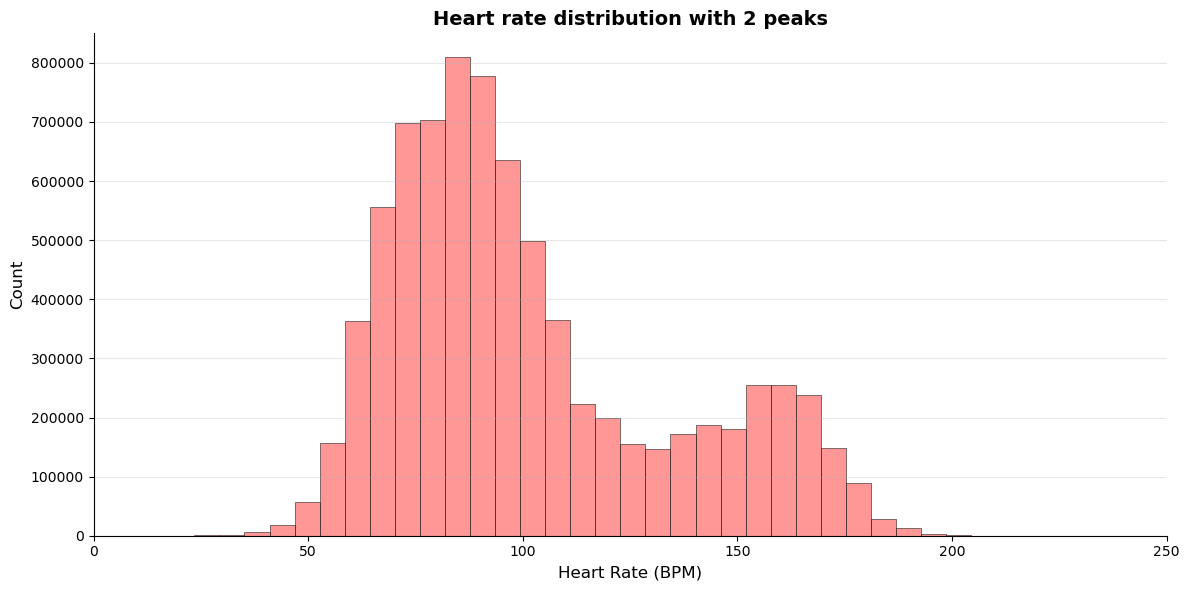

Mean heart rate: 101.4 BPM
Median heart rate: 92.0 BPM
Standard deviation: 32.8 BPM


In [20]:
# Heart Rate Distribution - Replicating the first plot
print("📊 Creating Heart Rate Distribution Plot")

# Create the main heart rate distribution plot
plt.figure(figsize=(12, 6))

# Plot histogram with bins similar to the original
plt.hist(heart_rate_data['valuenum'], bins=50, alpha=0.7, color='#FF6B6B', edgecolor='black', linewidth=0.5)
plt.title('Heart rate distribution with 2 peaks', fontsize=14, fontweight='bold')
plt.xlabel('Heart Rate (BPM)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Set x-axis limits to match the original
plt.xlim(0, 250)
plt.xticks(range(0, 251, 50))

# Add some styling to match the original
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print statistics
print(f"Mean heart rate: {heart_rate_data['valuenum'].mean():.1f} BPM")
print(f"Median heart rate: {heart_rate_data['valuenum'].median():.1f} BPM")
print(f"Standard deviation: {heart_rate_data['valuenum'].std():.1f} BPM")


Loaded 58976 admissions
Adults (18-89 years): 48149 admissions
Mean ages - Female: 63.10, Male: 61.27


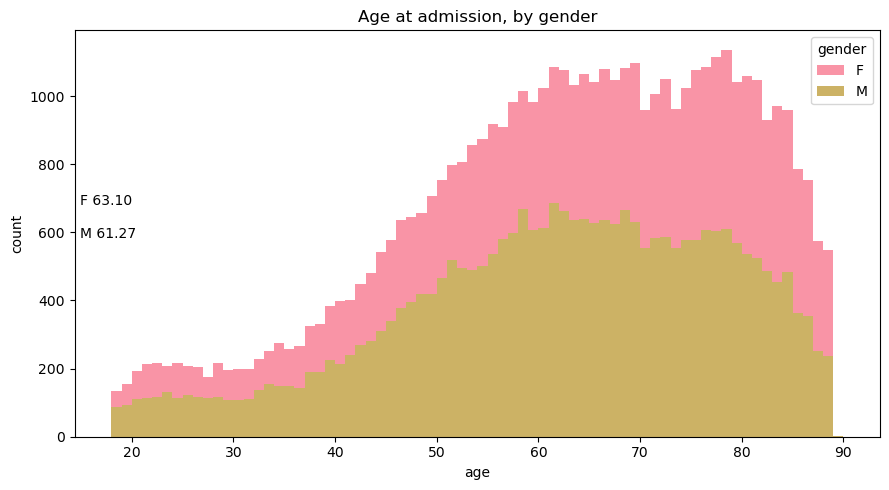


📊 Summary Statistics:
Total admissions: 48,149
Female admissions: 20,598
Male admissions: 27,551

Age distribution by gender:
        count   mean  median    std
gender                             
F       20598  63.10    66.0  16.88
M       27551  61.27    63.0  16.12


In [24]:
# Query adapted for MIMIC-III database structure
query = """
SELECT
  p.gender,
  EXTRACT(YEAR FROM AGE(a.admittime, p.dob))::int AS age_at_admit
FROM mimiciii.admissions a
JOIN mimiciii.patients p USING (subject_id)
WHERE a.admittime IS NOT NULL AND p.dob IS NOT NULL
"""

# Use your database connection
df = db.query_df(query)

print(f"Loaded {len(df)} admissions")

# keep adults, exclude de-identified ages
df = df[(df["age_at_admit"] >= 18) & (df["age_at_admit"] < 90)]

print(f"Adults (18-89 years): {len(df)} admissions")

# mean ages for annotation
means = df.groupby("gender")["age_at_admit"].mean().round(2)
mean_F = float(means.get("F", float("nan")))
mean_M = float(means.get("M", float("nan")))

print(f"Mean ages - Female: {mean_F:.2f}, Male: {mean_M:.2f}")

plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x="age_at_admit",
    hue="gender",
    bins=range(18, 91),     # 1-year bins
    multiple="stack",       # stacked bars like the example
    edgecolor=None
)
plt.title("Age at admission, by gender")
plt.xlabel("age")
plt.ylabel("count")

# annotate means on the left
ymin, ymax = plt.ylim()
xmin, xmax = plt.xlim()
x_annot = xmin + 0.5
if pd.notna(mean_F):
    plt.text(x_annot, ymax * 0.58, f"F {mean_F:.2f}", ha="left", va="center")
if pd.notna(mean_M):
    plt.text(x_annot, ymax * 0.50, f"M {mean_M:.2f}", ha="left", va="center")

plt.tight_layout()
plt.show()

# Additional statistics
print(f"\n📊 Summary Statistics:")
print(f"Total admissions: {len(df):,}")
print(f"Female admissions: {len(df[df['gender'] == 'F']):,}")
print(f"Male admissions: {len(df[df['gender'] == 'M']):,}")

# Age distribution by gender
print(f"\nAge distribution by gender:")
age_stats = df.groupby('gender')['age_at_admit'].agg(['count', 'mean', 'median', 'std']).round(2)
print(age_stats)


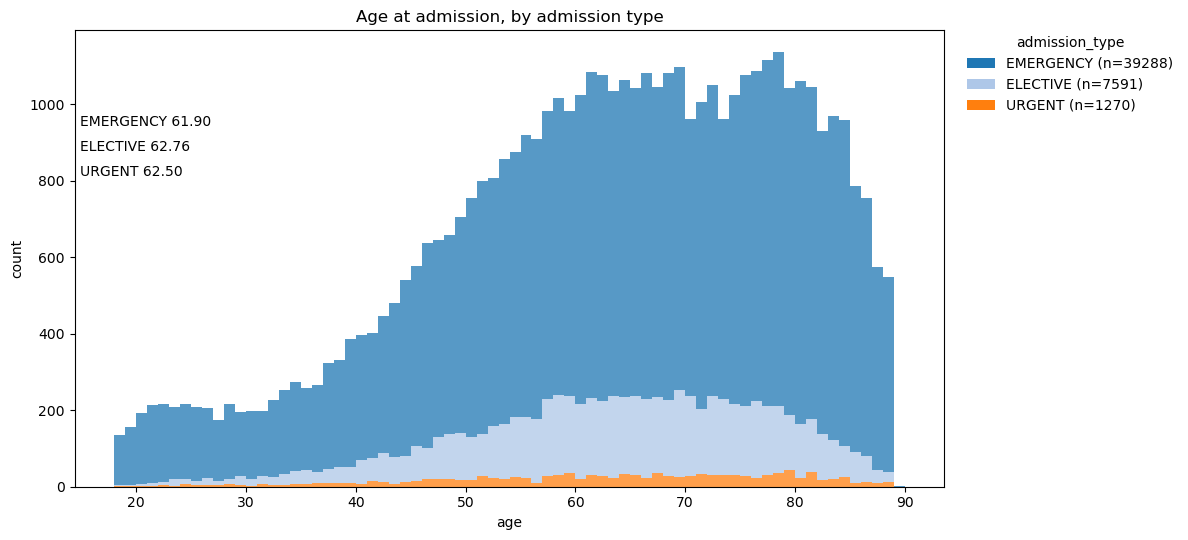

In [49]:
# Age at hospital admission, by admission_type (ALL types, stacked) — fixed colors + full legend

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

query = """
SELECT
  a.admission_type,
  EXTRACT(YEAR FROM AGE(a.admittime, p.dob))::int AS age_at_admit
FROM mimiciii.admissions a
JOIN mimiciii.patients  p USING (subject_id)
WHERE a.admittime IS NOT NULL AND p.dob IS NOT NULL
"""
df = db.query_df(query)

# normalize labels
df["admission_type"] = (
    df["admission_type"].str.upper().str.strip().replace({"EW EMER.": "EMERGENCY"})
)

# adults only; drop de-identified 90+; optionally exclude NEWBORN
df = df[(df["age_at_admit"] >= 18) & (df["age_at_admit"] < 90)]
df = df[df["admission_type"] != "NEWBORN"]   # remove this line if you want every type

# order by frequency
type_order = df["admission_type"].value_counts().index.tolist()
df["admission_type"] = pd.Categorical(df["admission_type"], categories=type_order, ordered=True)

# means for annotation
means = df.groupby("admission_type")["age_at_admit"].mean().round(2)

# choose a stable discrete palette with enough colors
palette = sns.color_palette("tab20", n_colors=len(type_order))
color_map = dict(zip(type_order, palette))

plt.figure(figsize=(12, 5.5))
ax = sns.histplot(
    data=df,
    x="age_at_admit",
    hue="admission_type",
    hue_order=type_order,
    bins=range(18, 91),
    multiple="stack",
    edgecolor=None,
    palette=color_map,
    legend=False,   # we'll build our own legend
)

plt.title("Age at admission, by admission type")
plt.xlabel("age")
plt.ylabel("count")

# manual legend with counts
counts = df["admission_type"].value_counts()
handles = [Patch(facecolor=color_map[t], label=f"{t} (n={counts[t]})") for t in type_order]
ax.legend(
    handles=handles,
    title="admission_type",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0.0,
    frameon=False,
)

# annotate mean ages on the left
ymin, ymax = plt.ylim()
xmin, xmax = plt.xlim()
x_annot = xmin + 0.5
ypos = ymax * 0.80
step = ymax * 0.055
for t in type_order:
    plt.text(x_annot, ypos, f"{t} {means.get(t, float('nan')):.2f}", ha="left", va="center", fontsize=10)
    ypos -= step
    if ypos < ymax * 0.05:
        break  # remove to print all labels even if they overflow

plt.tight_layout()
plt.show()


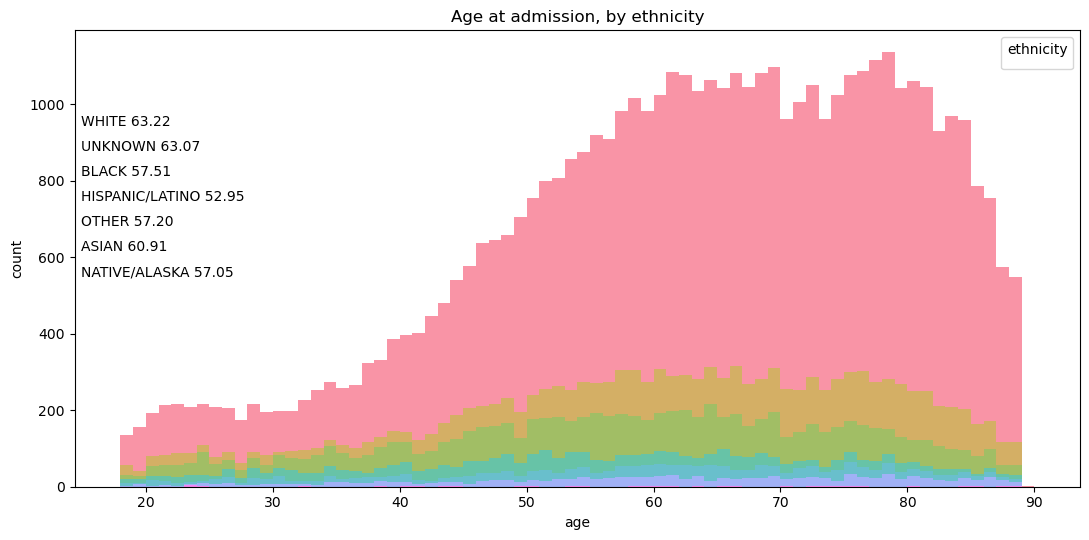

In [32]:
# Age at admission, by ethnicity (stacked)

import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Query age at hospital admission + raw ethnicity from MIMIC-III
query = """
SELECT
  a.ethnicity,
  EXTRACT(YEAR FROM AGE(a.admittime, p.dob))::int AS age_at_admit
FROM mimiciii.admissions a
JOIN mimiciii.patients  p USING (subject_id)
WHERE a.admittime IS NOT NULL AND p.dob IS NOT NULL
"""
df = db.query_df(query)   # or: pd.read_sql(query, engine)

# 2) Normalize/Collapse ethnicity labels -> broad buckets
def norm_eth(x: str) -> str:
    if not isinstance(x, str):
        return "UNKNOWN"
    s = x.upper().strip()

    # Common groupings in MIMIC-III
    if "WHITE" in s:
        return "WHITE"
    if "BLACK" in s or "AFRICAN" in s:
        return "BLACK"
    if "HISPANIC" in s or "LATINO" in s:
        return "HISPANIC/LATINO"
    if "ASIAN" in s:
        return "ASIAN"
    if "MIDDLE EASTERN" in s or "PORTUGUESE" in s:
        return "OTHER"
    if "NATIVE" in s or "AMERICAN INDIAN" in s or "ALASKA" in s:
        return "NATIVE/ALASKA"
    if "PACIFIC ISLANDER" in s or "HAWAIIAN" in s:
        return "PACIFIC ISLANDER"
    if "OTHER" in s:
        return "OTHER"
    if "UNKNOWN" in s or "NOT SPECIFIED" in s or "UNABLE TO OBTAIN" in s or "PATIENT DECLINED" in s:
        return "UNKNOWN"
    return "OTHER"

df["ethnicity_group"] = df["ethnicity"].map(norm_eth)

# 3) Adults only; exclude de-identified 90+
df = df[(df["age_at_admit"] >= 18) & (df["age_at_admit"] < 90)]

# 4) Order legend by frequency (most common first)
order = df["ethnicity_group"].value_counts().index.tolist()
df["ethnicity_group"] = pd.Categorical(df["ethnicity_group"], categories=order, ordered=True)

# 5) Means for annotation
means = df.groupby("ethnicity_group")["age_at_admit"].mean().round(2)

# 6) Plot
plt.figure(figsize=(11, 5.5))
sns.histplot(
    data=df,
    x="age_at_admit",
    hue="ethnicity_group",
    hue_order=order,
    bins=range(18, 91),    # 1-year bins
    multiple="stack",
    edgecolor=None,
)
plt.title("Age at admission, by ethnicity")
plt.xlabel("age")
plt.ylabel("count")
plt.legend(title="ethnicity", loc="upper right")

# 7) Annotate mean ages on the left
ymin, ymax = plt.ylim()
xmin, xmax = plt.xlim()
x_annot = xmin + 0.5
ypos = ymax * 0.80
step = ymax * 0.055
for grp in order:
    plt.text(x_annot, ypos, f"{grp} {means.get(grp, float('nan')):.2f}", ha="left", va="center", fontsize=10)
    ypos -= step
    if ypos < ymax * 0.05:
        break  # remove if you want to print *all* groups even if they overflow

plt.tight_layout()
plt.show()


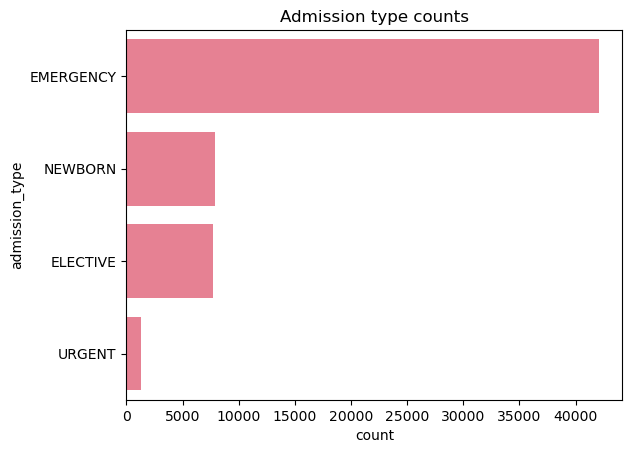

In [34]:
df = db.query_df("SELECT UPPER(TRIM(admission_type)) AS admission_type FROM mimiciii.admissions;")
df["admission_type"] = df["admission_type"].replace({"EW EMER.":"EMERGENCY"})
ax = sns.countplot(data=df, y="admission_type", order=df["admission_type"].value_counts().index)
ax.set_title("Admission type counts"); ax.set_xlabel("count"); ax.set_ylabel("admission_type"); plt.show()


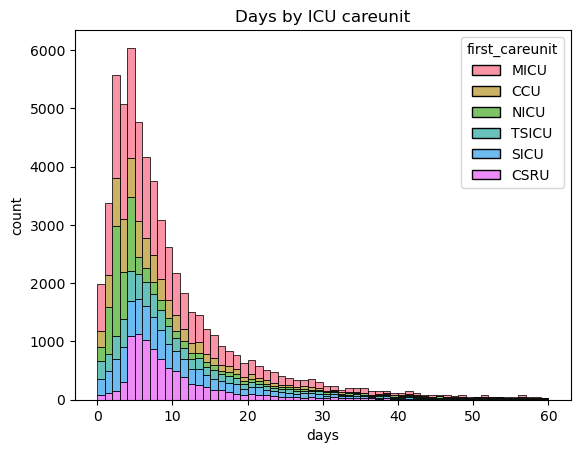

In [42]:
df = db.query_df("""
SELECT i.first_careunit,
       EXTRACT(EPOCH FROM (a.dischtime - a.admittime))/86400.0 AS los_days
FROM mimiciii.admissions a
JOIN mimiciii.icustays   i USING (hadm_id)
WHERE a.admittime IS NOT NULL AND a.dischtime IS NOT NULL;
""")
df = df[(df.los_days>=0) & (df.los_days<60)]
sns.histplot(data=df, x="los_days", hue="first_careunit", multiple="stack", bins=60)
plt.title("Days by ICU careunit"); plt.xlabel("days"); plt.ylabel("count"); plt.show()


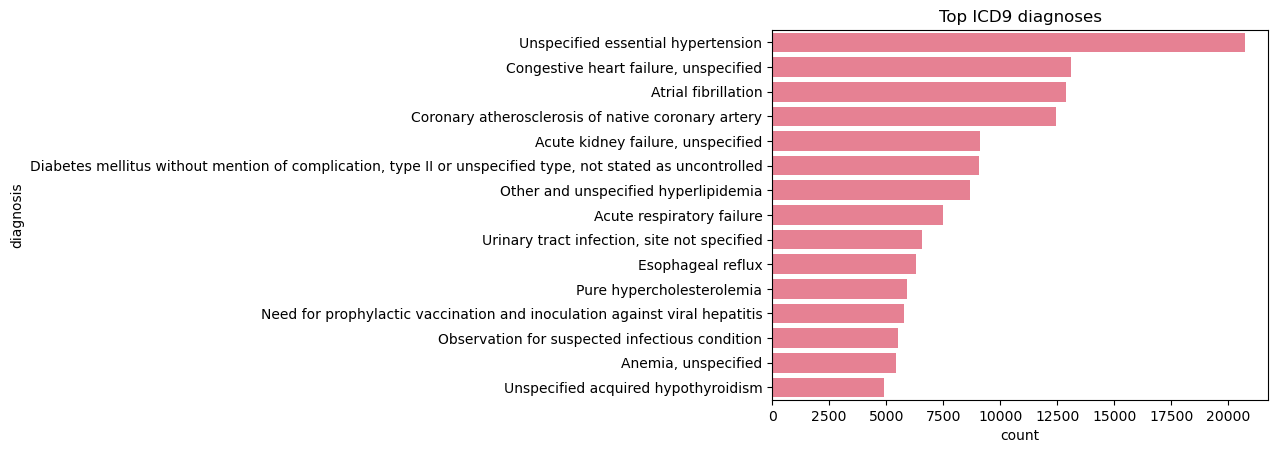

In [36]:
import seaborn as sns, matplotlib.pyplot as plt
df = db.query_df("""
SELECT d.long_title, COUNT(*) AS n
FROM mimiciii.diagnoses_icd di
JOIN mimiciii.d_icd_diagnoses d ON di.icd9_code=d.icd9_code
GROUP BY d.long_title
ORDER BY n DESC
LIMIT 15;
""")
sns.barplot(data=df, y="long_title", x="n")
plt.title("Top ICD9 diagnoses"); plt.xlabel("count"); plt.ylabel("diagnosis"); plt.show()


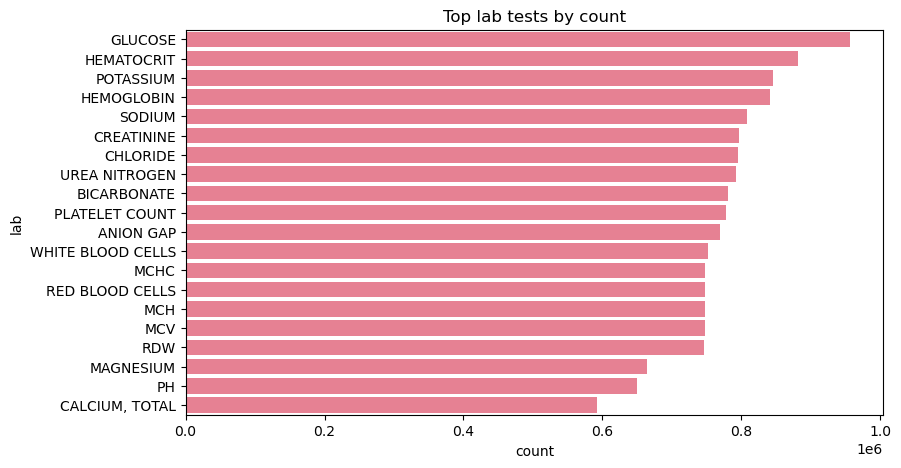

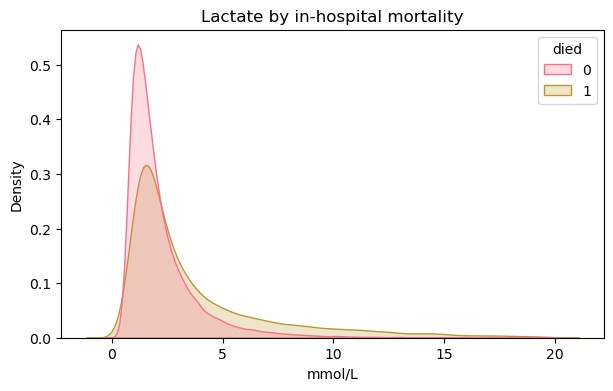

In [40]:
# Top labs and lactate distribution by hospital mortality

import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

sql_top = """
SELECT UPPER(TRIM(d.label)) AS lab, COUNT(*) AS n
FROM mimiciii.labevents l
JOIN mimiciii.d_labitems d ON l.itemid=d.itemid
WHERE l.valuenum IS NOT NULL
GROUP BY lab
ORDER BY n DESC
LIMIT 20;
"""
top = db.query_df(sql_top)

plt.figure(figsize=(9,5))
sns.barplot(data=top, y="lab", x="n")
plt.title("Top lab tests by count"); plt.xlabel("count"); plt.ylabel("lab")
plt.show()

sql_lac = """
SELECT a.hospital_expire_flag::int AS died, l.valuenum::float AS lactate
FROM mimiciii.labevents l
JOIN mimiciii.d_labitems d ON l.itemid=d.itemid
JOIN mimiciii.admissions a USING (hadm_id)
WHERE d.label ILIKE '%lactate%' AND l.valuenum IS NOT NULL;
"""
lac = db.query_df(sql_lac)
lac = lac[(lac["lactate"]>0) & (lac["lactate"]<20)]

plt.figure(figsize=(7,4))
sns.kdeplot(data=lac, x="lactate", hue="died", common_norm=False, fill=True)
plt.title("Lactate by in-hospital mortality"); plt.xlabel("mmol/L"); plt.show()


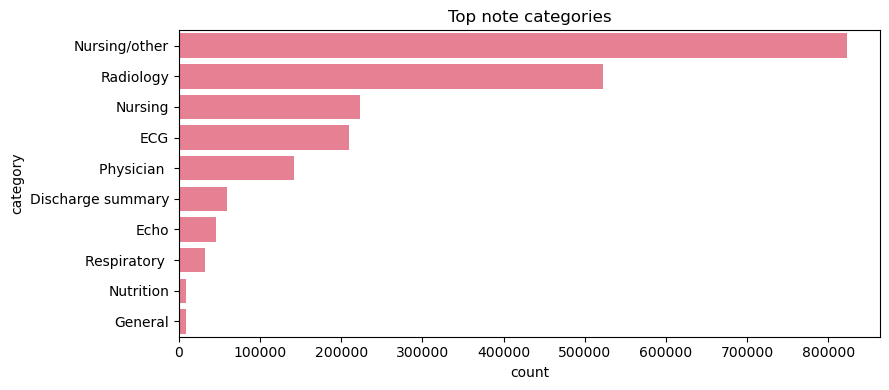

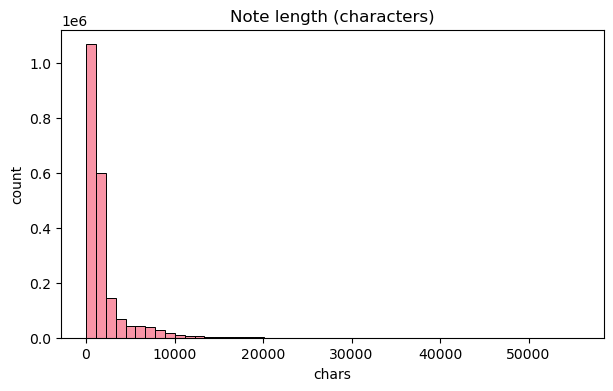

In [43]:
# Note counts by category + token length histogram

import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

sql = """
SELECT category, char_length(text) AS nchar
FROM mimiciii.noteevents
WHERE text IS NOT NULL
"""
notes = db.query_df(sql)
notes["category"] = notes["category"].fillna("UNKNOWN")

plt.figure(figsize=(9,4))
top_cats = notes["category"].value_counts().head(10).index.tolist()
sns.countplot(data=notes[notes["category"].isin(top_cats)],
              y="category", order=top_cats)
plt.title("Top note categories"); plt.xlabel("count"); plt.ylabel("category")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
sns.histplot(notes["nchar"], bins=50)
plt.title("Note length (characters)"); plt.xlabel("chars"); plt.ylabel("count")
plt.show()
